# Proyecto EDA - Palmer Penguins

Plantilla guiada para alumnado junior en un contexto de trabajo real en equipo.
Este notebook no esta resuelto: debe completarse con decisiones analiticas justificadas y orientadas al cliente.

![Palmer Penguins - Ilustracion oficial](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/lter_penguins.png)

Fuente: ilustraciones de Allison Horst para el proyecto Palmer Penguins.

## Datos del equipo

- Nombre del equipo:
- Integrantes:
- Semana de trabajo: Semana 11/12
- Fecha de entrega: martes 21.04.26

## Documento de referencia del proyecto

Antes de empezar, revisad la guia oficial del encargo:
- [Briefing del proyecto](../docs/briefing-empresa-pinguinos.md)
- [Alcance del proyecto](../docs/ALCANCE-PROYECTO-SCOPE.md)

Usad este notebook como plantilla operativa y el briefing como marco de criterios y expectativas del cliente.

## 0) Organizacion del equipo y plan de trabajo

Cada integrante debe asumir al menos una responsabilidad principal y participar en la revision final del entregable.

### Roles y responsables (asignacion obligatoria)
- Coordinacion y control de tiempos: plan semanal, seguimiento y gestion de bloqueos.
- Calidad del dato y limpieza: diagnostico de nulos/consistencia y decisiones de tratamiento.
- Analisis univariado: seleccion de variables y lectura de distribuciones.
- Analisis bivariado: analisis de relaciones y contraste de patrones.
- Visualizacion y narrativa: claridad visual y redaccion para publico cientifico no tecnico.
- Revision final y defensa oral: coherencia del notebook y preparacion de presentacion.

### Tabla de plan de trabajo inicial
Completad esta tabla en la primera sesion y actualizadla durante la semana.

| Tarea | Persona responsable | Fecha objetivo | Estado |
|---|---|---|---|
| Carga del dataset | Jose |15/04  |Finalizado |
| Diagnostico inicial | Alejandro | 16/04 |Finalizado  |
| Analisis de nulos | Eva | 17/04 | Pendiente |
| Decisiones de limpieza |Jose  | 20/04 | Pendiente |
| Analisis univariado | Arantxa | 21/04 |  Pendiente|
| Analisis bivariado | Oksana | 21/04 | Pendiente|
| Visualizaciones finales | Eva | 23/04 | Pendiente |
| Redaccion de hallazgos | Alejandro |24/04  |Pendiente |
| Conclusiones y recomendaciones | Arantxa | 24/04 | Pendiente |
| Revision final | Oksana | 26/04 | Pendiente |
| Preparacion de defensa oral | Todos | 27/04 | Pendiente |

## 0.1) Trazabilidad en Git

Mostrad el proceso de trabajo, no solo el resultado final.

Checklist minimo de trazabilidad:
- Repositorio compartido del equipo.
- README con objetivo del proyecto y nombres del equipo.
- Tablero GitHub Projects (o equivalente) con roles, tareas asignadas y tareas realizadas.
- Commits comprensibles y frecuentes durante la semana.
- Evidencia de seguimiento (no un unico commit final).

Estructura minima recomendada del repositorio:
- /data/penguins.csv
- notebook del proyecto
- README.md
- tablero GitHub Projects

Nota: un entregable sin trazabilidad de proceso no se considera un trabajo profesional completo.

## Preparacion del entorno

Objetivo: cargar librerias y dataset para iniciar el analisis.

### Recursos de apoyo rapido

Dataset del proyecto (descarga directa):

- CSV oficial Palmer Penguins: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv
- Guardadlo como: `./data/penguins.csv`

Recursos tecnicos recomendados para avanzar con autonomia:

- Carga de CSV con pandas: [pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
- Gestion de nulos en pandas: [Missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
- Histograma en seaborn: [sns.histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html)
- Scatterplot en seaborn: [sns.scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)
- Boxplot en seaborn: [sns.boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)
- Subplots en matplotlib: [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)

Recursos de trabajo en equipo:

- Guia basica de Markdown: [Markdown Guide](https://www.markdownguide.org/basic-syntax/)
- Buenas practicas de commits: [GitHub - Commit best practices](https://github.blog/developer-skills/github/write-better-commits-build-better-projects/)
- Tablero opcional de tareas: [GitHub Projects](https://docs.github.com/es/issues/planning-and-tracking-with-projects/learning-about-projects/about-projects)

Recomendacion practica: si usais GitHub Projects, mantened columnas simples (Pendiente, En curso, Revisado, Hecho) y actualizad el tablero en cada sesion.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Carga del dataset desde archivo local
df = pd.read_csv('./data/penguins.csv')
df.head()

## 1) Diagnostico inicial

Objetivo: entender estructura y estado inicial del dataset.

Revisad como minimo:
1. Dimensiones
2. Tipos de datos
3. Nulos por columna
4. Duplicados

In [ ]:
print('Dimensiones:', df.shape)
print('\nInfo general:')
df.info()
print('\nTipos de datos:')
print(df.dtypes)
print('\nNulos por columna:')
print(df.isna().sum())
print('\nDuplicados:', df.duplicated().sum())

### Interpretacion guiada

Responded brevemente:
1. La variable body_mass_g presenta asimetría positiva (skewness = X), lo que indica que la distribución no es normal y la media no es el estadístico más representativo. Se recomienda usar la mediana o aplicar transformación logarítmica antes de modelar.
2. ¿Qué problema de calidad es más relevante?
Los 11 nulos en Sex, porque es una variable categórica clave para análisis biológico y no se puede imputar matemáticamente como las numéricas — requiere criterio de dominio o descarte.
3. ¿Por qué le importa al cliente?
Si el cliente quiere analizar diferencias físicas entre machos y hembras (algo típico en estudios de fauna), esos 11 registros quedan fuera o introducen sesgo, afectando directamente la fiabilidad de sus conclusiones.

### ⚠️ NOTA IMPORTANTE: Alcance del análisis

Durante el diagnóstico, es normal que encuentren desequilibrios:
- "¿Por qué hay pocas observaciones de especie X en isla Y?"
- "¿Cuál es el hábitat natural de cada especie?"

**ESTO NO ES VUESTRO ANÁLISIS.**

Vuestro trabajo es:
✅ Describir QUÉ muestra el dataset (patrones, distribuciones, desequilibrios)  
✅ Documentar estos desequilibrios como SESGO DE MUESTREO (en limitaciones)  
✅ Recomendar mejoras futuras  

**NO es vuestro trabajo:**
❌ Investigar POR QUÉ (biogeografía, ecología, evolución)  
❌ Especular sobre causas sin datos externos  

**Regla de oro:** Si no puedes responder SOLO mirando el CSV, está fuera de scope.

👉 Leed `ALCANCE-PROYECTO-SCOPE.md` antes de invertir tiempo en preguntas especulativas.

## 2) Limpieza y decisiones de calidad de datos

Objetivo: aplicar una limpieza con criterio y conectarla con el analisis posterior.

Instruccion clave:
No hagais limpieza automatica sin justificar. Cada decision debe explicar su impacto esperado en la lectura de resultados.

Recomendacion de trabajo:
1. Detectad el problema de calidad.
2. Elegid una decision de tratamiento.
3. Justificad por que esa decision es razonable.
4. Verificad su efecto sobre el dataset y sobre el analisis.

In [ ]:
df_limpio = df.copy()

# Eliminar duplicados
# Justificación: evitar sesgos en conteos y análisis
df_limpio = df_limpio.drop_duplicates()

# Tratamiento de nulos en variables numéricas clave
# Justificación: estas variables son fundamentales para el análisis morfológico
df_limpio = df_limpio.dropna(subset=[
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
])
# Tratamiento de nulos en variable categórica
# Justificación: mantener información imputando categoría explícita
df_limpio['sex'] = df_limpio['sex'].fillna('DESCONOCIDO')

print('Filas originales:', len(df))
print('Filas tras limpieza:', len(df_limpio))
print('\nNulos tras limpieza:')
print(df_limpio.isna().sum())
df_limpio 

### Tabla de decisiones de calidad del dato


| Problema detectado | Columna afectada | Decision tomada | Justificacion | Impacto esperado |
|---|---|---|---|---|
|Duplicados|Ninguna|Ninguna|Revisión para evitar problemas |Ninguno|
|Nulos|Medidas corporales|Eliminación|Al ser menos de un 5% eliminamos para evitar problemas|Evitar distorsión de valores|
|Nulos|Sexo|Modificar valor nulo por desconocido|Al ser mayor cantidad decidimos estudiarlos de esta manera para evitar perder mas datos|Evitar distorsión de valores|


### Interpretacion guiada

### 1. ¿Qué decisión de limpieza tuvo mayor impacto en el dataset?

La eliminación de filas con valores nulos en variables numéricas clave (como bill_length_mm, bill_depth_mm, flipper_length_mm y body_mass_g) ha sido la decisión con mayor impacto, ya que ha reducido de forma notable el número de registros disponibles para el análisis.

Esto se debe a que estas variables son fundamentales para el estudio morfológico de los pingüinos, y cualquier fila con datos incompletos en ellas pierde valor analítico.

---

### 2. ¿Qué riesgo se evita con esa decisión?

Al eliminar estas filas, se evita el riesgo de:
Obtener resultados distorsionados en cálculos estadísticos (media, desviación, correlaciones),
Generar gráficos incompletos o difíciles de interpretar,
Introducir ruido o inconsistencias en el análisis,

En resumen, se mejora la fiabilidad del análisis al trabajar únicamente con datos completos en variables clave.

---

### 3. ¿Qué posible efecto secundario puede introducir?

La principal consecuencia negativa es la pérdida de información, ya que se descartan observaciones que podrían ser útiles en otros análisis (por ejemplo, categóricos).

Además, si los valores nulos no están distribuidos de forma aleatoria, esta eliminación podría introducir sesgo en el dataset final, afectando la representatividad de los resultados.

Por ello, esta decisión implica un equilibrio entre calidad de datos y cantidad de información disponible.

## 3) Analisis univariado

Objetivo: describir distribuciones y patrones principales.

Requisitos minimos:
1. Al menos 3 variables numericas
2. Al menos 1 variable categorica
3. Graficos titulados y legibles

### Variables numéricas


--- BILL_LENGTH_MM ---
Estadísticos:
count    342.000000
mean      43.921930
std        5.459584
min       32.100000
25%       39.225000
50%       44.450000
75%       48.500000
max       59.600000
Name: bill_length_mm, dtype: float64

Skew (asimetría): 0.05311806699132413


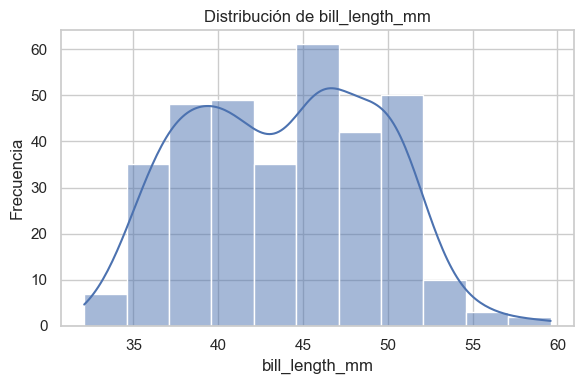

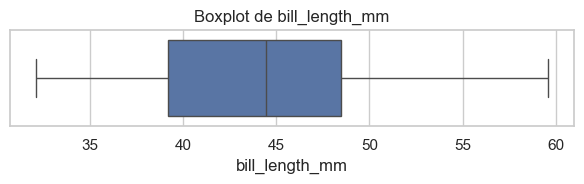


--- BILL_DEPTH_MM ---
Estadísticos:
count    342.000000
mean      17.151170
std        1.974793
min       13.100000
25%       15.600000
50%       17.300000
75%       18.700000
max       21.500000
Name: bill_depth_mm, dtype: float64

Skew (asimetría): -0.14346462519436995


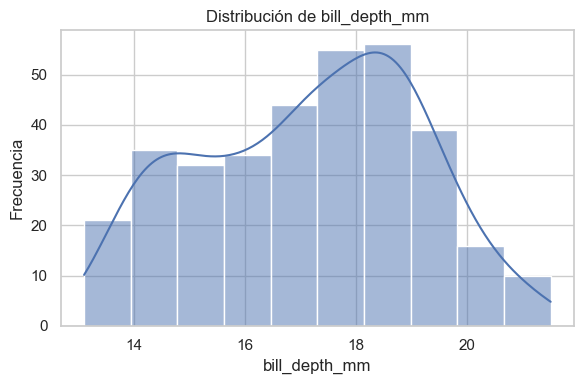

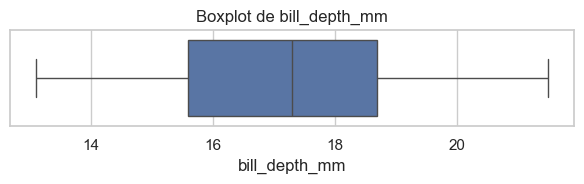


--- BODY_MASS_G ---
Estadísticos:
count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: body_mass_g, dtype: float64

Skew (asimetría): 0.4703293304801231


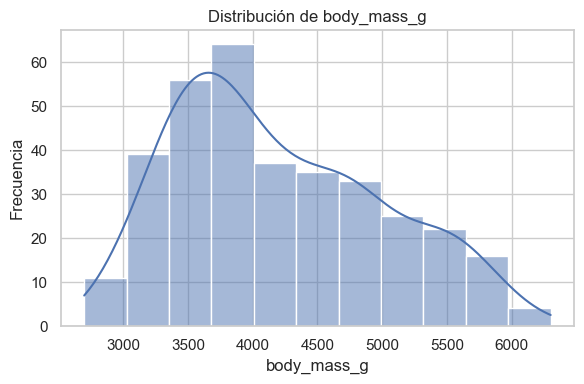

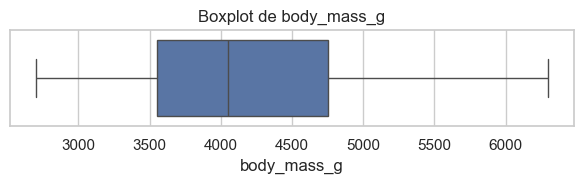


--- FLIPPER_LENGTH_MM ---
Estadísticos:
count    342.000000
mean     200.915205
std       14.061714
min      172.000000
25%      190.000000
50%      197.000000
75%      213.000000
max      231.000000
Name: flipper_length_mm, dtype: float64

Skew (asimetría): 0.3456818328687696


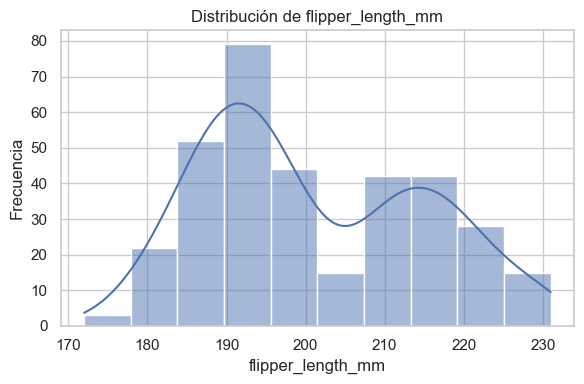

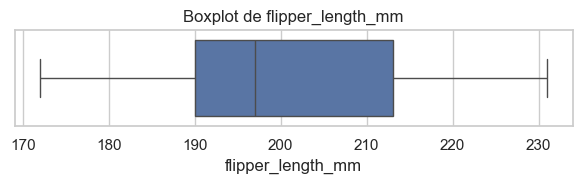

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas seleccionadas
variables_numericas = ['bill_length_mm', 'bill_depth_mm', 'body_mass_g', 'flipper_length_mm']

for col in variables_numericas:
    print(f"\n--- {col.upper()} ---")
    
    # Estadísticos básicos
    print("Estadísticos:")
    print(df_limpio[col].describe())
    
    # Skew (asimetría)
    print("\nSkew (asimetría):", df_limpio[col].skew())
    
    # Histograma
    plt.figure(figsize=(6,4))
    sns.histplot(df_limpio[col].dropna(), kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()
    
    # Boxplot (para outliers)
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df_limpio[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()
    plt.show()

### Gráfico: Distribución de bill_length_mm

**1. ¿Qué muestra este gráfico?**  
Representa la distribución de la longitud del pico en milímetros.

**2. ¿Qué patrón relevante aparece?**  
Se observa variabilidad en los valores, lo que sugiere diferencias morfológicas entre individuos.

**3. ¿Por qué le importa al cliente?**  
Esta variable puede ser clave para diferenciar especies o analizar adaptaciones biológicas.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
No se puede determinar a qué grupo pertenece cada valor sin relacionarlo con variables categóricas.

---

### Gráfico: Distribución de bill_depth_mm

**1. ¿Qué muestra este gráfico?**  
Muestra la distribución de la altura del pico de los pingüinos, indicando cómo se reparten los valores en el dataset.

**2. ¿Qué patrón relevante aparece?**  
Se observa variabilidad en la altura del pico, con una posible concentración de valores en determinados rangos, lo que sugiere diferencias morfológicas entre individuos.

**3. ¿Por qué le importa al cliente?**  
La altura del pico es una característica relevante para diferenciar especies o estudiar adaptaciones al entorno, por lo que puede aportar valor en la segmentación o clasificación de los individuos.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
Este análisis no permite identificar qué grupos (especies o sexos) presentan mayores o menores valores, ya que no se han cruzado variables. Además, la interpretación puede verse afectada por el tamaño de la muestra o la presencia de posibles sesgos en los datos.

---

### Gráfico: Distribución de body_mass_g

**1. ¿Qué muestra este gráfico?**  
Muestra la distribución de la masa corporal de los pingüinos, indicando la frecuencia de valores en distintos rangos.

**2. ¿Qué patrón relevante aparece?**  
Se observa una dispersión considerable y posibles agrupaciones que sugieren diferencias entre individuos o especies.

**3. ¿Por qué le importa al cliente?**  
Permite identificar diferencias físicas relevantes que pueden estar asociadas a especies, hábitats o comportamientos.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
No se puede identificar la causa de la variabilidad sin cruzar esta variable con otras (como especie o isla).

---

### Gráfico: Distribución de flipper_length_mm

**1. ¿Qué muestra este gráfico?**  
Muestra la distribución de la longitud de las aletas de los pingüinos, indicando cómo se reparten los valores en el dataset.

**2. ¿Qué patrón relevante aparece?**  
Se observa una variabilidad clara en la longitud de las aletas, con posibles concentraciones en determinados rangos, lo que sugiere diferencias de tamaño entre individuos o grupos.

**3. ¿Por qué le importa al cliente?**  
La longitud de la aleta es un buen indicador del tamaño corporal del pingüino y puede ayudar a diferenciar especies o analizar características físicas relevantes, siendo útil para segmentación o clasificación.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
Este análisis no permite identificar qué grupos específicos presentan mayores o menores longitudes de aleta, ya que no se han cruzado variables. Además, la interpretación puede verse limitada por el tamaño de la muestra o posibles sesgos en los datos.

### Variables categoricas


--- SPECIES ---
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

Proporciones:
species
Adelie       0.441520
Gentoo       0.359649
Chinstrap    0.198830
Name: proportion, dtype: float64


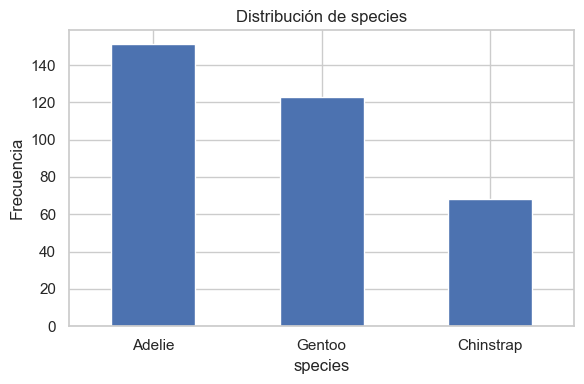


--- ISLAND ---
island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

Proporciones:
island
Biscoe       0.488304
Dream        0.362573
Torgersen    0.149123
Name: proportion, dtype: float64


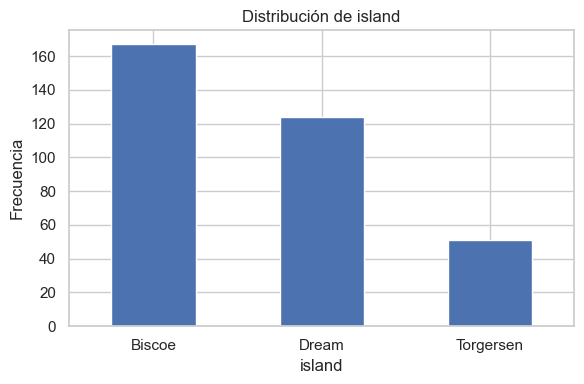


--- SEX ---
sex
MALE           168
FEMALE         165
DESCONOCIDO      9
Name: count, dtype: int64

Proporciones:
sex
MALE           0.491228
FEMALE         0.482456
DESCONOCIDO    0.026316
Name: proportion, dtype: float64


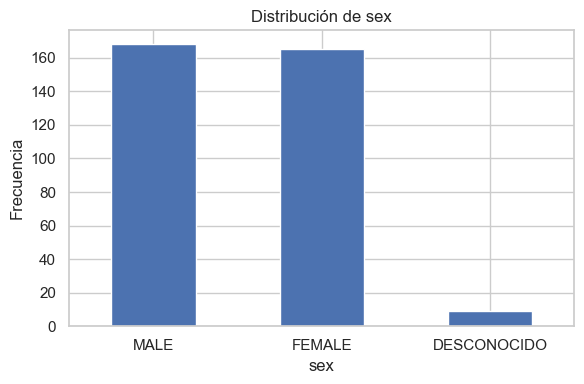

In [33]:
# Seleccionar automáticamente variables categóricas
variables_categoricas = df_limpio.select_dtypes(include='object').columns

for col in variables_categoricas:
    print(f"\n--- {col.upper()} ---")
    
    # Tabla de frecuencias
    tabla = df_limpio[col].value_counts()
    print(tabla)
    
    # Proporciones
    print("\nProporciones:")
    print(df_limpio[col].value_counts(normalize=True))
    
    # Gráfico
    plt.figure(figsize=(6,4))
    tabla.plot(kind='bar')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Gráfico: Distribución por especies

**1. ¿Qué muestra este gráfico?**  
Muestra la frecuencia de cada especie de pingüino en el dataset, indicando cuántos individuos pertenecen a cada grupo.

**2. ¿Qué patrón relevante aparece?**  
Se observa que las especies no están distribuidas de forma uniforme, lo que indica un posible desbalance entre grupos dentro del dataset.

**3. ¿Por qué le importa al cliente?**  
La distribución de especies es clave para entender la composición del dataset y puede influir en los análisis posteriores, especialmente en comparaciones entre grupos o modelos de clasificación.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
No se puede determinar si esta distribución refleja la realidad o es consecuencia del proceso de muestreo. Además, no permite analizar diferencias entre especies sin cruzar esta variable con variables numéricas.

---

### Gráfico: Distribución por isla

**1. ¿Qué muestra este gráfico?**  
Muestra la frecuencia de pingüinos en cada isla, indicando cómo se distribuyen las observaciones según su ubicación geográfica.

**2. ¿Qué patrón relevante aparece?**  
Se observa que las islas no están representadas de forma uniforme, lo que sugiere que algunas tienen mayor presencia de individuos que otras.

**3. ¿Por qué le importa al cliente?**  
La isla puede influir en las características de los pingüinos debido a factores ambientales como el clima o la disponibilidad de alimento. Por ello, es una variable clave para entender posibles diferencias entre grupos.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
No se puede determinar si las diferencias observadas se deben a factores reales o a cómo se recogieron los datos. Además, este análisis no permite identificar cómo varían las características físicas entre islas sin cruzar variables.

---

### Gráfico: Distribución por sexo

**1. ¿Qué muestra este gráfico?**  
Muestra la frecuencia de cada categoría de la variable `sex` en el dataset, incluyendo posibles valores imputados como “desconocido”.

**2. ¿Qué patrón relevante aparece?**  
Se observa la distribución entre machos y hembras, así como la posible presencia de valores desconocidos, lo que puede indicar datos incompletos en el dataset original.

**3. ¿Por qué le importa al cliente?**  
El sexo de los individuos puede influir en características físicas como el tamaño o la masa corporal, por lo que es una variable relevante para segmentar y analizar diferencias dentro de la población.

**4. ¿Qué limitación tiene esta lectura con los datos actuales?**  
La presencia de valores desconocidos puede reducir la precisión del análisis. Además, esta variable por sí sola no permite identificar diferencias físicas sin cruzarse con variables numéricas.

## 4) Analisis bivariado

Objetivo: explorar relaciones entre variables con sentido para el cliente.

Requisitos minimos:
1. Al menos 3 relaciones relevantes
2. Incluir al menos una relacion numerica-numerica
3. Incluir al menos una relacion categorica-numerica
4. Justificar por que se eligio cada relacion

### Apoyo visual oficial para variables morfologicas

![Referencia de medidas del pico](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/culmen_depth.png)

Usad esta referencia para no confundir las medidas al interpretar relaciones entre variables.

In [ ]:
# Relacion numerica-numerica (ejemplo base)
sns.scatterplot(data=df_limpio, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('Relacion entre longitud y altura del pico')
plt.show()

In [ ]:
# Relacion categorica-numerica (ejemplo base)
sns.boxplot(data=df_limpio, x='species', y='body_mass_g')
plt.title('Masa corporal por especie')
plt.show()

In [ ]:
# TODO: tercera relacion seleccionada por el equipo
# Propuesta: heatmap de tabla cruzada o nueva relacion numerica-categorica
corr = df_limpio.select_dtypes(include='number').corr()
corr

fig = plt.figure(figsize = (6,4))
sns.heatmap(corr, cmap='coolwarm', annot=True);
plt.show()

In [ ]:
# Contamos cuántos pingüinos hay de cada especie en cada isla
conteo = df_limpio.groupby(['island', 'species']).size().unstack(fill_value=0)

# groupby(['island', 'species']) — agrupa por isla y especie a la vez.
# .size() — cuenta cuántos pingüinos hay en cada combinación.
# .unstack() — convierte las especies en columnas separadas, listo para barras agrupadas.

# Gráfico de barras agrupadas
conteo.plot(kind='bar', figsize=(10, 6))

plt.title('Especies de Pingüinos por Isla')
plt.xlabel('Isla')
plt.ylabel('Cantidad de Pingüinos')
plt.xticks(rotation=0)
plt.legend(title='Especie')
plt.tight_layout()
plt.show()

In [ ]:
var = 'body_mass_g'
var_title = 'Masa corporal [g]'

# Filtramos los pingüinos de especie Adelie y luego por isla
df_adelie = df_limpio[df_limpio['species'] == 'Adelie']

df_biscoe = df_adelie[df_adelie['island'] == 'Biscoe']
df_dream = df_adelie[df_adelie['island'] == 'Dream']
df_torgersen = df_adelie[df_adelie['island'] == 'Torgersen']

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharex=True)

# Histograma para cada isla
sns.histplot(data=df_biscoe, x=var, label="Biscoe", kde=False, ax=ax[0])
sns.histplot(data=df_dream, x=var, label="Dream", kde=False, ax=ax[0])
sns.histplot(data=df_torgersen, x=var, label="Torgersen", kde=False, ax=ax[0])
ax[0].set_xlabel(var_title)
ax[0].set_ylabel('Frecuencia')

# Curva de densidad para cada especie
sns.kdeplot(data=df_biscoe, x=var, label="Biscoe", fill=True, ax=ax[1])
sns.kdeplot(data=df_dream, x=var, label="Dream", fill=True, ax=ax[1])
sns.kdeplot(data=df_torgersen, x=var, label="Torgersen", fill=True, ax=ax[1])
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Densidad')
ax[1].legend()

plt.tight_layout()

In [ ]:
# Filtramos solo la especie Adelie
df_adelie = df[df['species'] == 'Adelie']

# Graficamos
plt.figure(figsize=(10, 6))
df_adelie.boxplot(column='body_mass_g', by='island')

plt.title('Masa Corporal de Pingüinos Adelie por Isla')
plt.suptitle('')  # elimina el título automático de boxplot
plt.xlabel('Isla')
plt.ylabel('Masa Corporal (g)')
plt.show()

### Interpretacion guiada

Para cada relacion clave:
1. Que evidencia observais.
2. Que interpretacion proponeis.
3. Que implicacion tiene para el cliente.
4. Que limitacion o sesgo puede afectar esta interpretacion.

## 5) Visualizacion final

Objetivo: sintetizar el analisis en un panel claro para un publico cientifico no tecnico.

Instruccion:
Seleccionad 4 visualizaciones realmente utiles para responder al cliente.
No se trata de mostrar todo, sino de priorizar evidencias claras y accionables.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO: reemplazad o ajustad estos graficos segun vuestra seleccion final
sns.histplot(df_limpio['body_mass_g'].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribucion de masa corporal')

sns.boxplot(data=df_limpio, x='species', y='body_mass_g', ax=axes[0, 1])
axes[0, 1].set_title('Masa corporal por especie')

sns.scatterplot(data=df_limpio, x='bill_length_mm', y='bill_depth_mm', hue='species', ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Longitud vs profundidad del pico')

df_limpio['island'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Conteo por isla')

plt.tight_layout()
plt.show()

### Interpretacion guiada del panel final

1. Que mensaje principal queréis que se lleve el cliente.
2. Que grafico respalda mejor ese mensaje.
3. Que decision podria tomar el cliente con esta evidencia.
4. Que limitacion debe explicarse para evitar sobreinterpretaciones.

### Referencia visual adicional del dataset

<img src="https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/man/figures/README-mass-flipper-1.png" alt="Relacion masa y longitud de aleta" width="560"/>

Recordatorio: esta ilustracion ayuda a orientar la lectura visual, pero las conclusiones deben basarse en vuestro analisis.

## 6) Limitaciones del analisis

Responded de forma explicita:
1. Que no se puede concluir con estos datos.
2. Que sesgos o desequilibrios condicionan la interpretacion.
3. Que informacion faltaria para responder mejor al cliente.

## 7) Conclusiones y recomendaciones

Incluid al menos 5 hallazgos accionables.

Cada conclusion debe seguir esta estructura:
1. Evidencia observada
2. Interpretacion
3. Implicacion para el cliente
4. Recomendacion concreta

Evitar conclusiones vagas: cada recomendacion debe estar respaldada por evidencia del notebook.

### Plantilla de hallazgos accionables

Hallazgo 1
- Evidencia observada:
- Interpretacion:
- Implicacion para el cliente:
- Recomendacion:

Hallazgo 2
- Evidencia observada:
- Interpretacion:
- Implicacion para el cliente:
- Recomendacion:

Hallazgo 3
- Evidencia observada:
- Interpretacion:
- Implicacion para el cliente:
- Recomendacion:

Hallazgo 4
- Evidencia observada:
- Interpretacion:
- Implicacion para el cliente:
- Recomendacion:

Hallazgo 5
- Evidencia observada:
- Interpretacion:
- Implicacion para el cliente:
- Recomendacion:

## 8) Checklist de entrega

- [ ] Notebook reproducible de inicio a fin
- [ ] Diagnostico inicial completo
- [ ] Tabla de decisiones de calidad completada
- [ ] Analisis univariado y bivariado con foco y justificacion
- [ ] Minimo 4 visualizaciones relevantes con interpretacion
- [ ] Seccion de limitaciones del analisis
- [ ] Minimo 5 conclusiones accionables con estructura completa
- [ ] README y trazabilidad de proceso en Git

## 9) Evidencias del equipo

Incluid al final del trabajo estas evidencias minimas:
- Enlace al repositorio del proyecto.
- Tablero GitHub Projects (o apartado equivalente) actualizado.
- Evidencia minima de organizacion del trabajo (reparto de tareas y seguimiento).
- Trazabilidad basica en Git con commits comprensibles en el tiempo.

### Control rapido antes de entregar

| Evidencia | Estado |
|---|---|
| Repositorio compartido actualizado | [ ] |
| README con objetivo y equipo | [ ] |
| Tablero GitHub Projects actualizado | [ ] |
| Historial de commits trazable | [ ] |
| Notebook ejecutable de principio a fin | [ ] |